# Wafer Defect Map - EDA (Exploratory Data Analysis)

## Dataset: WM-811K
- Total: 811,457 wafer samples
- Columns: waferMap, dieSize, lotName, waferIndex, trianTestLabel, failureType

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns
from collections import Counter

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

data_path = Path('data') / 'LSWMD_new.pkl'
df = pd.read_pickle(data_path)

print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


In [10]:
print("=== Sample Data (Top 5 rows) ===")
display(df.head())

print("\n=== Basic Statistics ===")
print(f"Total wafers: {len(df):,}")
print(f"Unique dieSize count: {df['dieSize'].nunique()}")
print(f"Unique lotName count: {df['lotName'].nunique()}")

print("\n=== failureType Unique Values ===")
failure_types = df['failureType'].apply(lambda x: x[0][0] if len(x) > 0 else 'none')
print(failure_types.value_counts())

=== Sample Data (Top 5 rows) ===


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]



=== Basic Statistics ===
Total wafers: 811,457
Unique dieSize count: 1266
Unique lotName count: 46293

=== failureType Unique Values ===
failureType
none         785938
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## 1. failureType Distribution

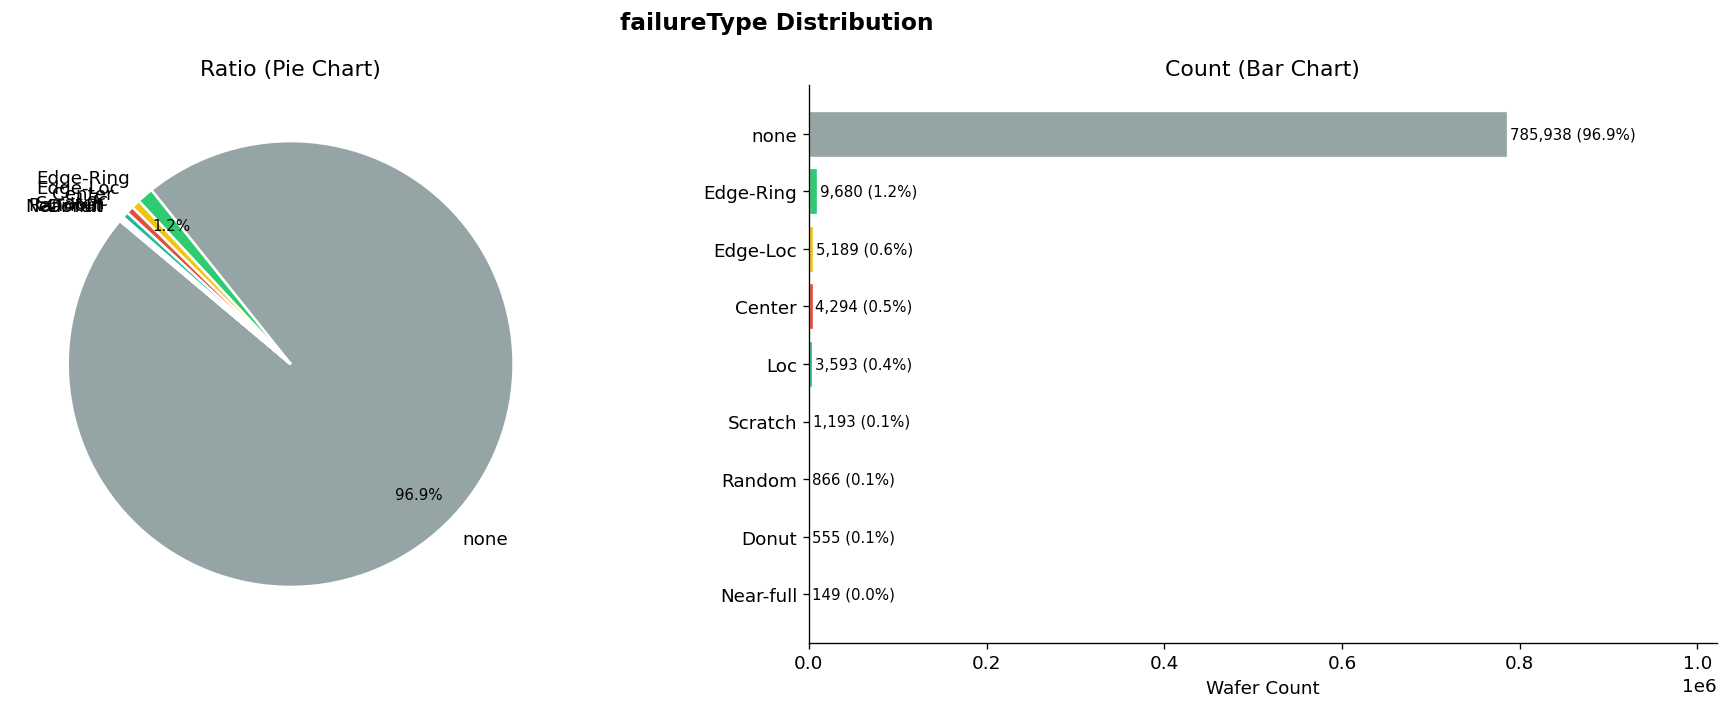


=== failureType Detail Statistics ===


,Count,Ratio(%)
failure_label,,
none,785938,96.86
Edge-Ring,9680,1.19
Edge-Loc,5189,0.64
Center,4294,0.53
Loc,3593,0.44
Scratch,1193,0.15
Random,866,0.11
Donut,555,0.07
Near-full,149,0.02


In [11]:
# Parse failureType
df['failure_label'] = df['failureType'].apply(lambda x: x[0][0] if len(x) > 0 else 'none')

failure_counts = df['failure_label'].value_counts()
total = len(df)

FAILURE_COLORS = {
    'none':      '#95a5a6',
    'Center':    '#e74c3c',
    'Donut':     '#e67e22',
    'Edge-Loc':  '#f1c40f',
    'Edge-Ring': '#2ecc71',
    'Loc':       '#1abc9c',
    'Random':    '#3498db',
    'Scratch':   '#9b59b6',
    'Near-full': '#e91e63',
}

colors = [FAILURE_COLORS.get(k, '#bdc3c7') for k in failure_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('failureType Distribution', fontsize=14, fontweight='bold')

# Pie Chart
wedges, texts, autotexts = axes[0].pie(
    failure_counts.values,
    labels=failure_counts.index,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Ratio (Pie Chart)')

# Bar Chart
bars = axes[1].barh(
    failure_counts.index[::-1],
    failure_counts.values[::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.8
)
for bar, val in zip(bars, failure_counts.values[::-1]):
    axes[1].text(
        bar.get_width() + 3000, bar.get_y() + bar.get_height() / 2,
        f'{val:,} ({val/total*100:.1f}%)',
        va='center', fontsize=9
    )
axes[1].set_xlabel('Wafer Count')
axes[1].set_title('Count (Bar Chart)')
axes[1].set_xlim(0, failure_counts.max() * 1.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== failureType Detail Statistics ===")
summary = pd.DataFrame({
    'Count': failure_counts,
    'Ratio(%)': (failure_counts / total * 100).round(2)
})
display(summary)

## 2. waferMap Size Distribution

=== waferMap dimension types: 632 ===
Most common size: (32, 29)  (108,687, 13.4%)
Smallest size: 6 x 3
Largest size:   300 x 205

=== Average waferMap Size (all wafers) ===
  Height: 45.06  |  Width: 43.12  |  Area: 1943.0 px²

=== Top 40 Sizes Coverage ===
  Wafers in top 40 sizes: 573,255 / 811,457  (70.65%)
  Remaining (other sizes): 238,202  (29.35%)

=== Average waferMap Size (top 40 sizes only) ===
  Height: 39.28  |  Width: 36.07  |  Area: 1416.6 px²


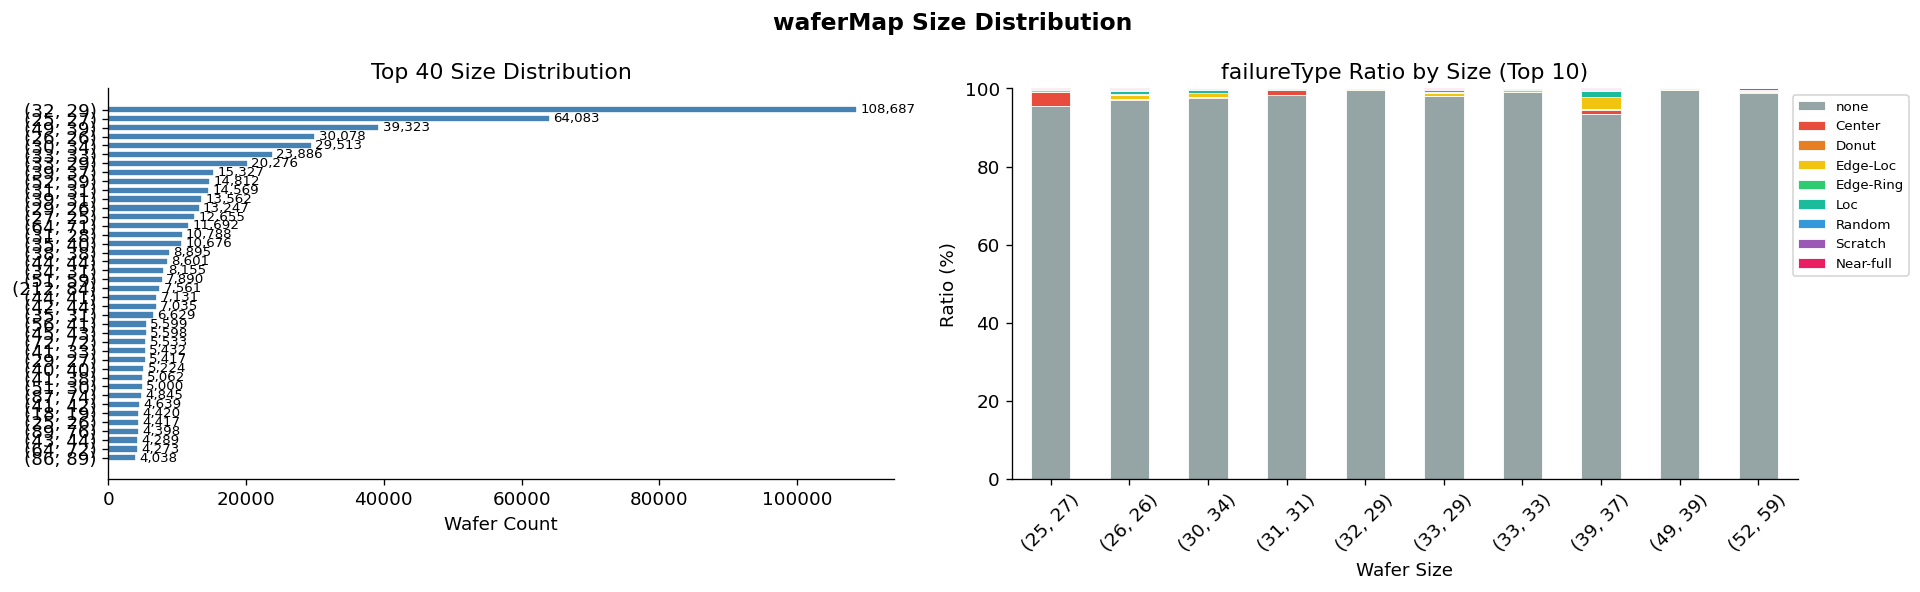


=== Top 10 Wafer Sizes Detail ===


,Count,Ratio
wafer_dim,,
"(32, 29)",108687,13.39
"(25, 27)",64083,7.90
"(49, 39)",39323,4.85
"(26, 26)",30078,3.71
"(30, 34)",29513,3.64
"(33, 33)",23886,2.94
"(33, 29)",20276,2.50
"(39, 37)",15327,1.89
"(52, 59)",14812,1.83


In [26]:
# Compute waferMap dimensions
df['wafer_dim'] = df['waferMap'].apply(lambda x: x.shape)
df['wafer_h'] = df['waferMap'].apply(lambda x: x.shape[0])
df['wafer_w'] = df['waferMap'].apply(lambda x: x.shape[1])

dim_counts = df['wafer_dim'].value_counts().head(40)

print(f"=== waferMap dimension types: {df['wafer_dim'].nunique()} ===")
print(f"Most common size: {dim_counts.index[0]}  ({dim_counts.iloc[0]:,}, {dim_counts.iloc[0]/total*100:.1f}%)")
print(f"Smallest size: {df['wafer_h'].min()} x {df['wafer_w'].min()}")
print(f"Largest size:   {df['wafer_h'].max()} x {df['wafer_w'].max()}")

# --- Overall average size ---
avg_h_all = df['wafer_h'].mean()
avg_w_all = df['wafer_w'].mean()
print(f"\n=== Average waferMap Size (all wafers) ===")
print(f"  Height: {avg_h_all:.2f}  |  Width: {avg_w_all:.2f}  |  Area: {avg_h_all * avg_w_all:.1f} px²")

# --- Top 40 coverage ---
top40_dims = df['wafer_dim'].value_counts().head(40)
top40_count = top40_dims.sum()
top40_pct = top40_count / total * 100
print(f"\n=== Top 40 Sizes Coverage ===")
print(f"  Wafers in top 40 sizes: {top40_count:,} / {total:,}  ({top40_pct:.2f}%)")
print(f"  Remaining (other sizes): {total - top40_count:,}  ({100 - top40_pct:.2f}%)")

# --- Average size within top 40 ---
top40_dim_list = top40_dims.index.tolist()
df_top40 = df[df['wafer_dim'].isin(top40_dim_list)]
avg_h_top40 = df_top40['wafer_h'].mean()
avg_w_top40 = df_top40['wafer_w'].mean()
print(f"\n=== Average waferMap Size (top 40 sizes only) ===")
print(f"  Height: {avg_h_top40:.2f}  |  Width: {avg_w_top40:.2f}  |  Area: {avg_h_top40 * avg_w_top40:.1f} px²")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('waferMap Size Distribution', fontsize=14, fontweight='bold')

# Top 20 sizes bar chart
labels = [str(d) for d in dim_counts.index]
axes[0].barh(labels[::-1], dim_counts.values[::-1], color='steelblue', edgecolor='white')
for i, (label, val) in enumerate(zip(labels[::-1], dim_counts.values[::-1])):
    axes[0].text(val + 500, i, f'{val:,}', va='center', fontsize=8)
axes[0].set_xlabel('Wafer Count')
axes[0].set_title('Top 40 Size Distribution')
axes[0].spines[['top', 'right']].set_visible(False)

# failureType distribution by size (top 10)
top_dims = dim_counts.head(10).index.tolist()
df_top = df[df['wafer_dim'].isin(top_dims)].copy()

dim_failure = df_top.groupby(['wafer_dim', 'failure_label']).size().unstack(fill_value=0)
dim_failure_pct = dim_failure.div(dim_failure.sum(axis=1), axis=0) * 100

failure_labels_order = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']
cols = [c for c in failure_labels_order if c in dim_failure_pct.columns]
plot_colors = [FAILURE_COLORS.get(c, '#bdc3c7') for c in cols]

dim_failure_pct[cols].plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=plot_colors,
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title('failureType Ratio by Size (Top 10)')
axes[1].set_xlabel('Wafer Size')
axes[1].set_ylabel('Ratio (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.15, 1))
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== Top 10 Wafer Sizes Detail ===")
display(dim_counts.head(10).rename('Count').to_frame().assign(Ratio=lambda x: (x['Count']/total*100).round(2)))

## 3. Train / Test Distribution

=== Train / Test Distribution ===
split_label
unlabeled    638507
Test         118595
Training      54355
Name: count, dtype: int64


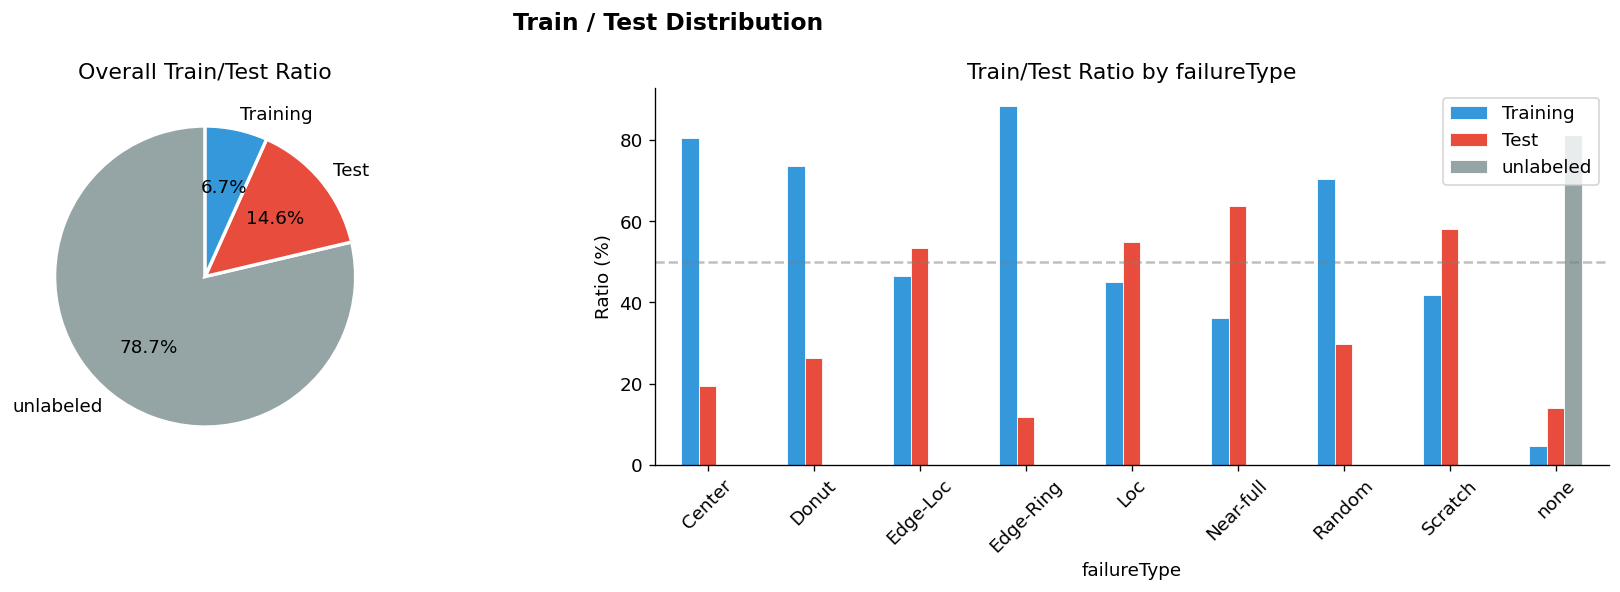


=== failureType x Train/Test Crosstab ===


split_label,Test,Training,unlabeled,All
failure_label,,,,
Center,832,3462,0,4294
Donut,146,409,0,555
Edge-Loc,2772,2417,0,5189
Edge-Ring,1126,8554,0,9680
Loc,1973,1620,0,3593
Near-full,95,54,0,149
Random,257,609,0,866
Scratch,693,500,0,1193
none,110701,36730,638507,785938


In [13]:
# Parse trianTestLabel
df['split_label'] = df['trianTestLabel'].apply(lambda x: x[0][0] if len(x) > 0 else 'unlabeled')

split_counts = df['split_label'].value_counts()
print("=== Train / Test Distribution ===")
print(split_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Train / Test Distribution', fontsize=14, fontweight='bold')

# Overall pie chart
split_colors = {'Training': '#3498db', 'Test': '#e74c3c', 'unlabeled': '#95a5a6'}
colors_split = [split_colors.get(k, '#bdc3c7') for k in split_counts.index]
axes[0].pie(
    split_counts.values,
    labels=split_counts.index,
    colors=colors_split,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Overall Train/Test Ratio')

# Train/Test Ratio by failureType
ct = pd.crosstab(df['failure_label'], df['split_label'], normalize='index') * 100
ct_cols = [c for c in ['Training', 'Test', 'unlabeled'] if c in ct.columns]
ct_plot_colors = [split_colors.get(c, '#bdc3c7') for c in ct_cols]

ct[ct_cols].plot(
    kind='bar',
    ax=axes[1],
    color=ct_plot_colors,
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title('Train/Test Ratio by failureType')
axes[1].set_xlabel('failureType')
axes[1].set_ylabel('Ratio (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n=== failureType x Train/Test Crosstab ===")
display(pd.crosstab(df['failure_label'], df['split_label'], margins=True))

## 4. dieSize Distribution

=== dieSize Basic Statistics ===
count    811457.000000
mean       1840.998585
std        2254.987374
min           3.000000
25%         710.000000
50%         953.000000
75%        1902.000000
max       48099.000000
Name: dieSize, dtype: float64

Unique count: 1266
Unique values: [np.float64(3.0), np.float64(12.0), np.float64(21.0), np.float64(31.0), np.float64(34.0), np.float64(50.0), np.float64(54.0), np.float64(60.0), np.float64(79.0), np.float64(82.0), np.float64(91.0), np.float64(96.0), np.float64(97.0), np.float64(106.0), np.float64(127.0), np.float64(131.0), np.float64(142.0), np.float64(154.0), np.float64(173.0), np.float64(174.0), np.float64(175.0), np.float64(209.0), np.float64(238.0), np.float64(260.0), np.float64(268.0), np.float64(281.0), np.float64(303.0), np.float64(353.0), np.float64(374.0), np.float64(379.0), np.float64(382.0), np.float64(390.0), np.float64(402.0), np.float64(409.0), np.float64(419.0), np.float64(433.0), np.float64(439.0), np.float64(443.0), np.float6

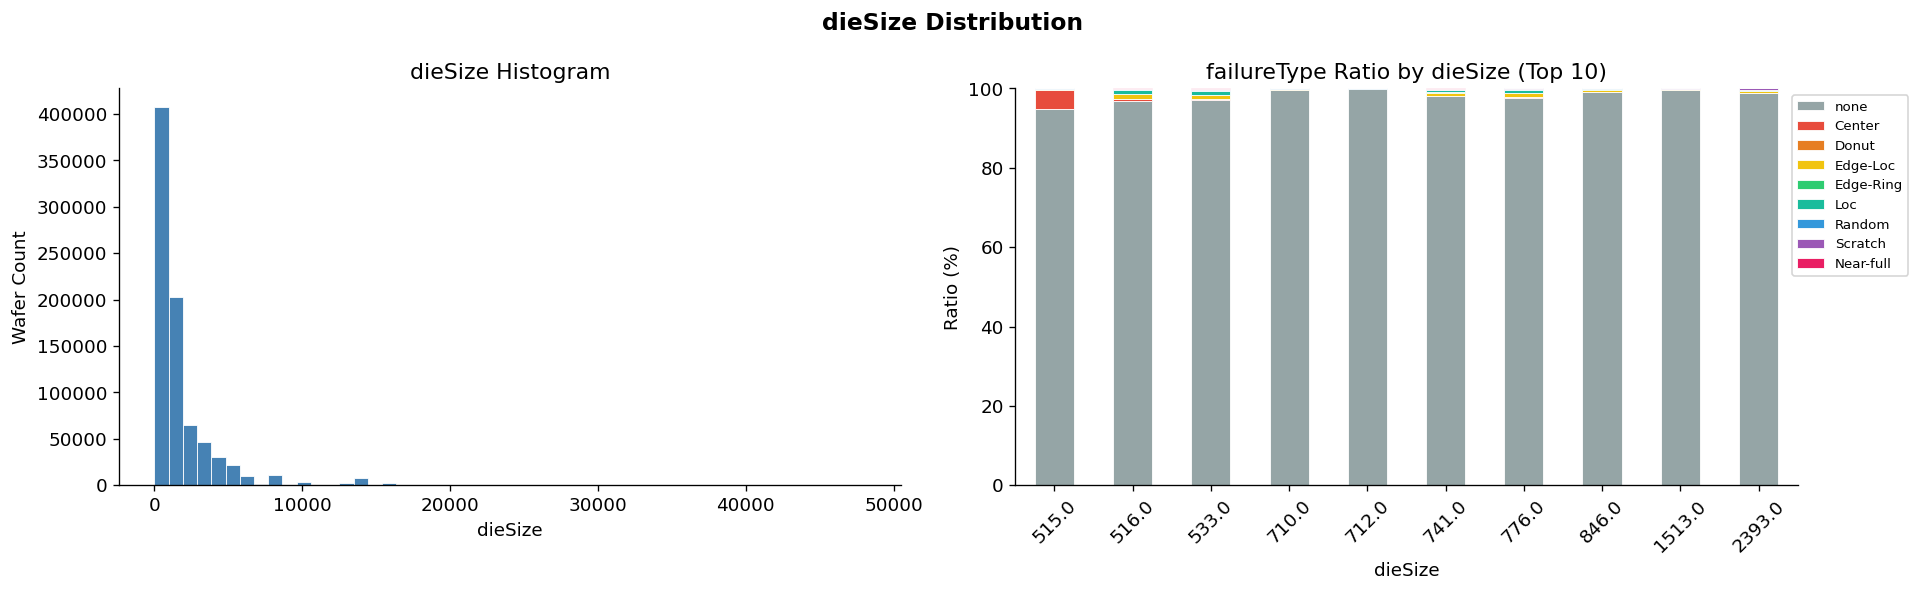

In [14]:
die_counts = df['dieSize'].value_counts().sort_index()

print("=== dieSize Basic Statistics ===")
print(df['dieSize'].describe())
print(f"\nUnique count: {df['dieSize'].nunique()}")
print(f"Unique values: {sorted(df['dieSize'].unique())}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('dieSize Distribution', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df['dieSize'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('dieSize')
axes[0].set_ylabel('Wafer Count')
axes[0].set_title('dieSize Histogram')
axes[0].spines[['top', 'right']].set_visible(False)

# failureType ratio by dieSize (top 10)
top_dies = die_counts.nlargest(10).index.tolist()
df_top_die = df[df['dieSize'].isin(top_dies)].copy()
die_failure = pd.crosstab(df_top_die['dieSize'], df_top_die['failure_label'], normalize='index') * 100

cols = [c for c in failure_labels_order if c in die_failure.columns]
plot_colors = [FAILURE_COLORS.get(c, '#bdc3c7') for c in cols]

die_failure[cols].plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=plot_colors,
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title('failureType Ratio by dieSize (Top 10)')
axes[1].set_xlabel('dieSize')
axes[1].set_ylabel('Ratio (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.15, 1))
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 5. waferMap Visualization by Failure Type

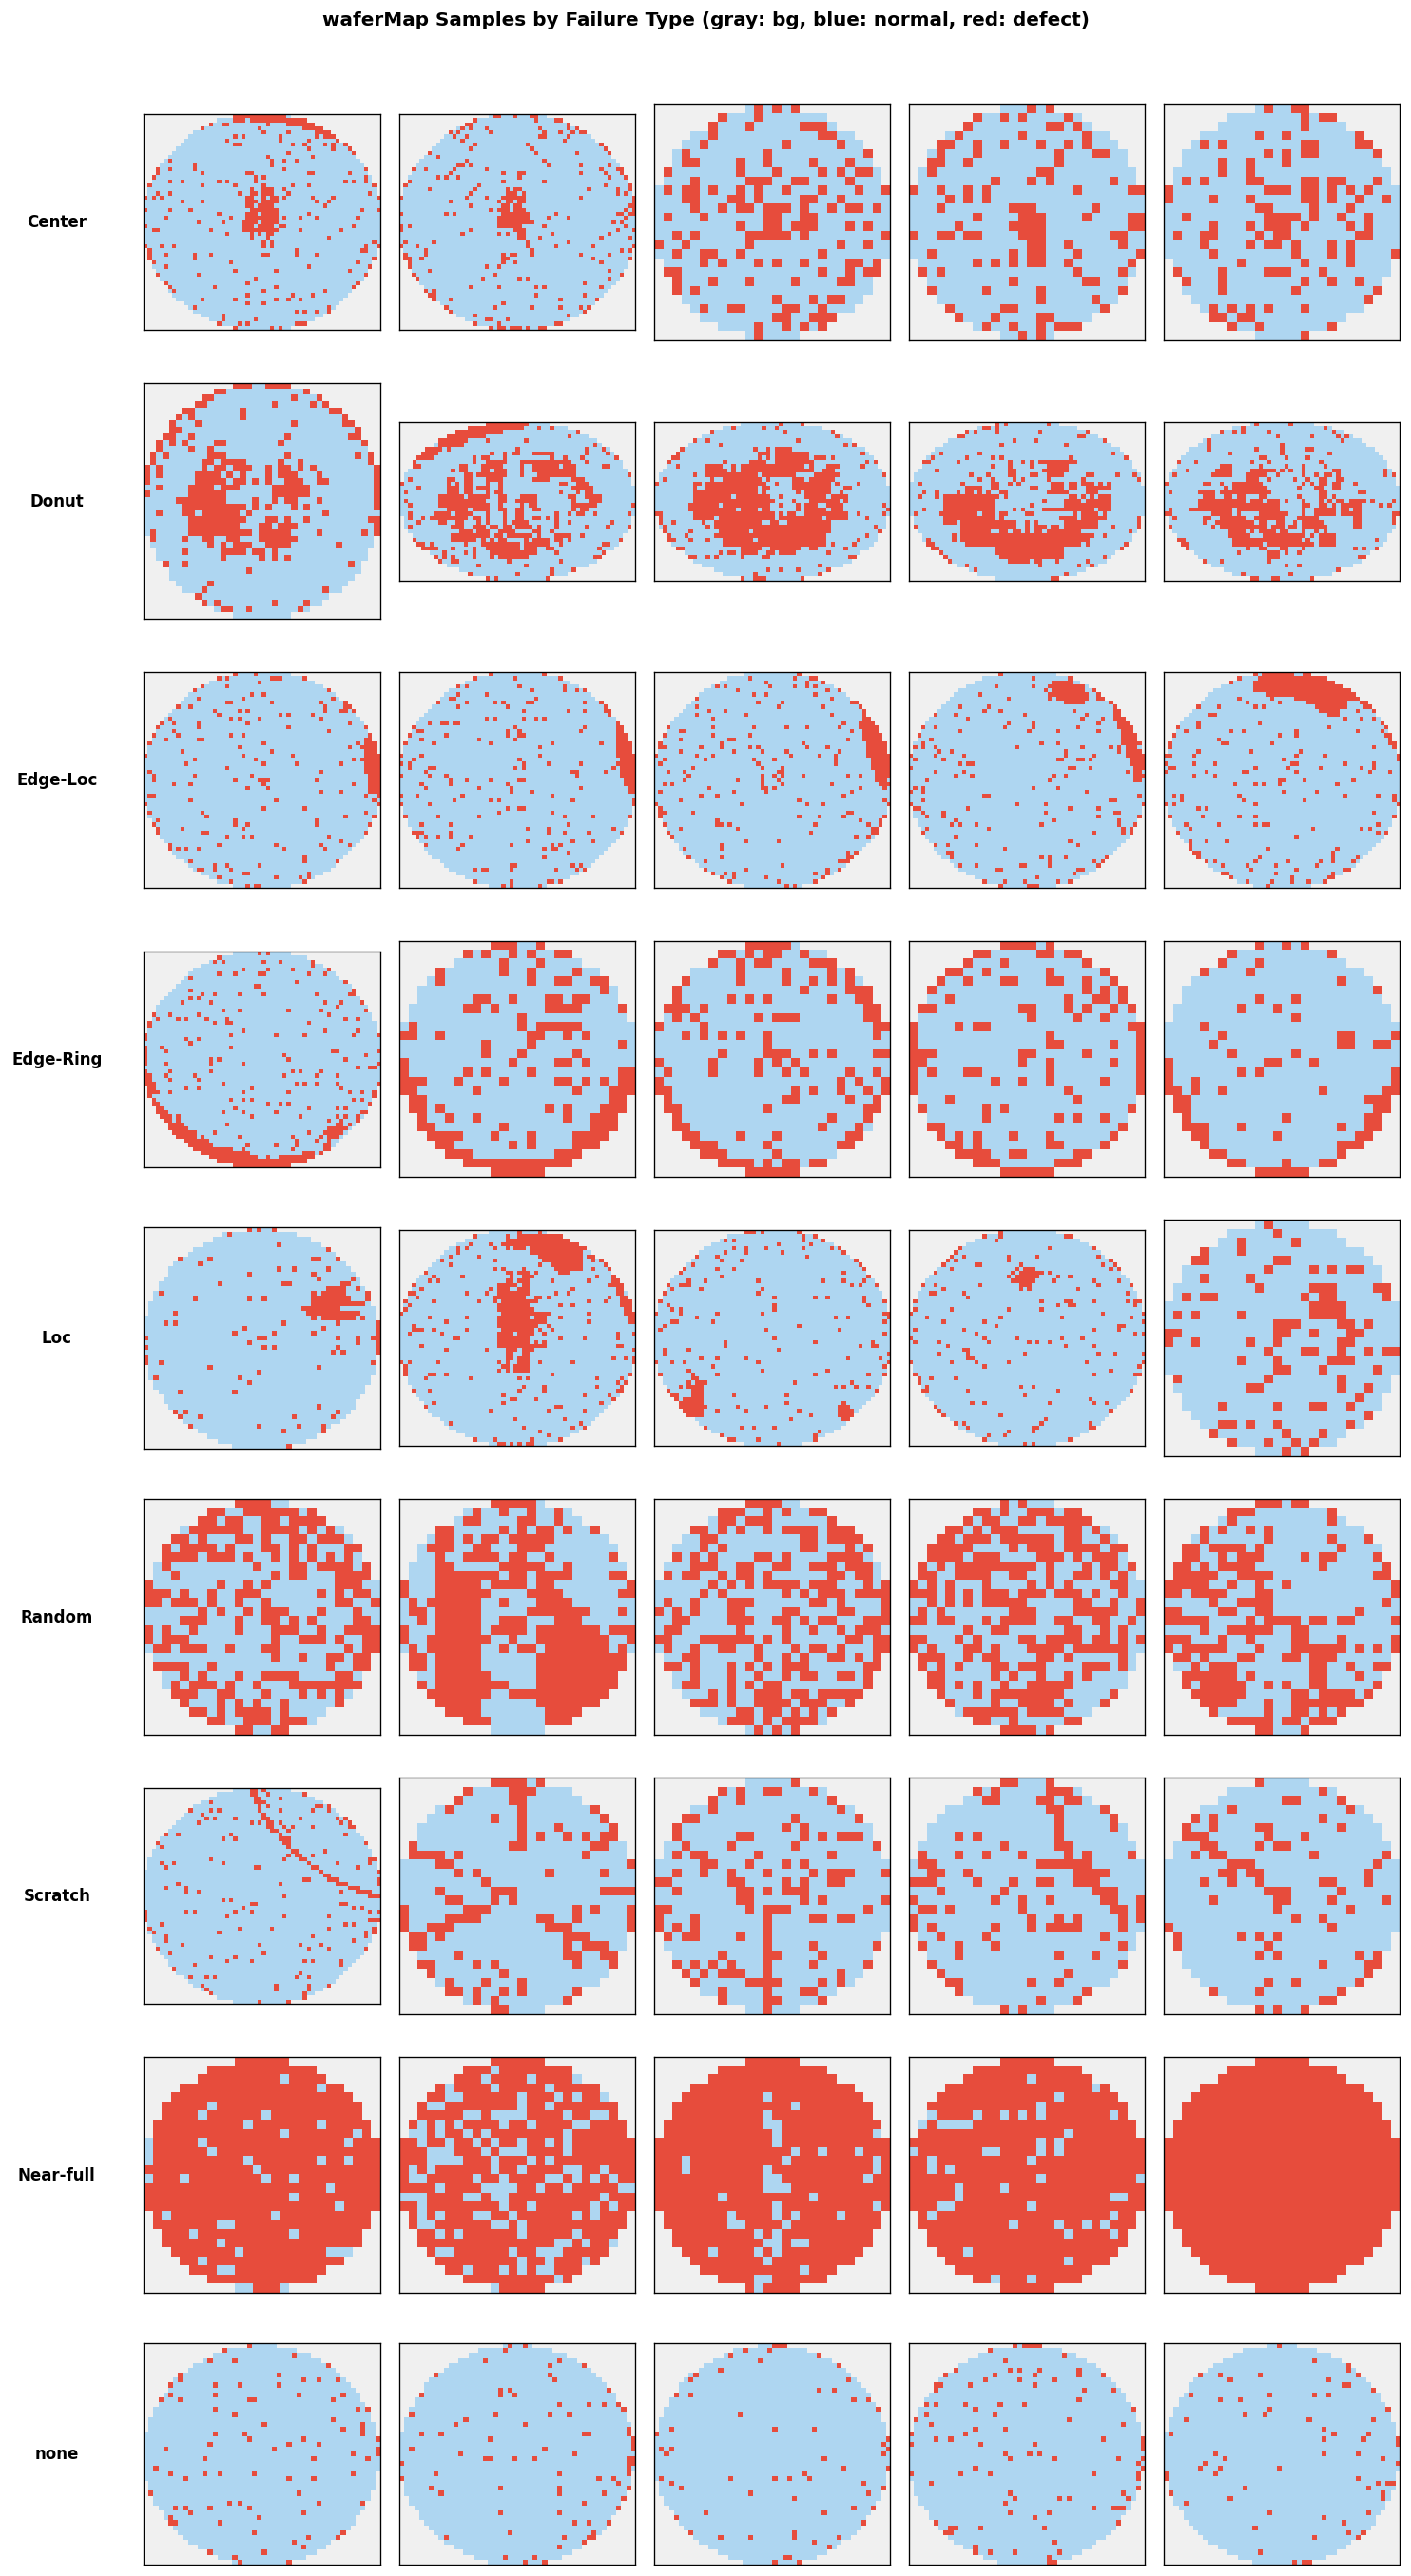

In [15]:
# waferMap sample visualization by failure type
# 0: background, 1: normal die, 2: defect die
wafer_cmap = ListedColormap(['#f0f0f0', '#aed6f1', '#e74c3c'])

defect_types = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full', 'none']
n_samples = 5

fig, axes = plt.subplots(len(defect_types), n_samples, figsize=(n_samples * 2.5, len(defect_types) * 2.5))
fig.suptitle('waferMap Samples by Failure Type (gray: bg, blue: normal, red: defect)',
             fontsize=12, fontweight='bold', y=1.01)

for row_idx, defect in enumerate(defect_types):
    samples = df[df['failure_label'] == defect]['waferMap'].head(n_samples)

    for col_idx in range(n_samples):
        ax = axes[row_idx][col_idx]

        if col_idx < len(samples):
            wafer = samples.iloc[col_idx]
            ax.imshow(wafer, cmap=wafer_cmap, vmin=0, vmax=2, interpolation='nearest')
        else:
            ax.axis('off')

        if col_idx == 0:
            ax.set_ylabel(defect, fontsize=10, fontweight='bold', rotation=0, labelpad=55, va='center')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

Computing defect die ratio... (this may take a while)


/var/folders/bv/pwm7yqld0kx5tnjqm191709c0000gn/T/ipykernel_19775/3615685785.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


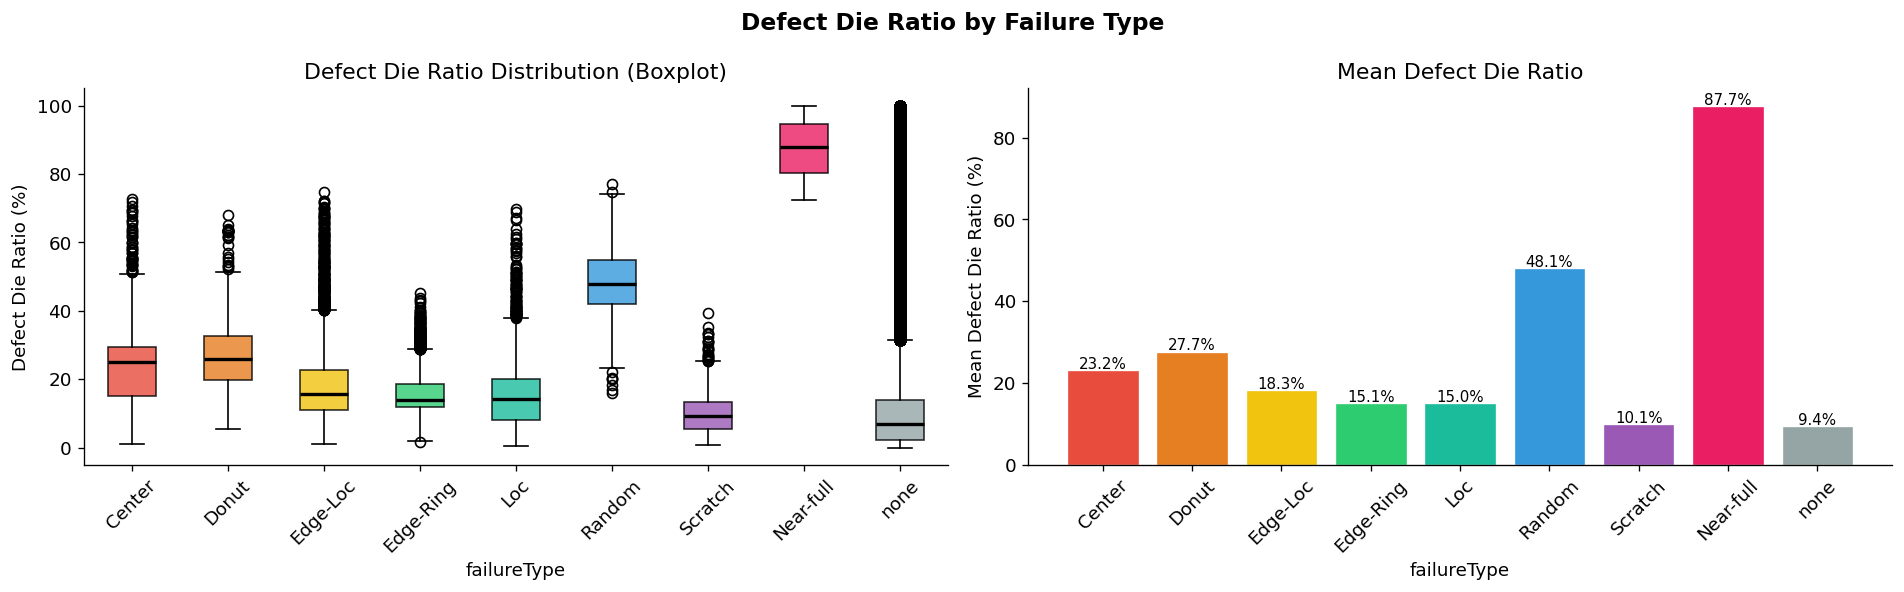


=== Defect Die Ratio Statistics by Failure Type ===


,count,mean,std,min,25%,50%,75%,max
failure_label,,,,,,,,
Center,4294.0,23.25,10.29,0.90,15.20,25.05,29.51,72.71
Donut,555.0,27.68,11.16,5.36,19.83,25.76,32.57,67.84
Edge-Loc,5189.0,18.28,10.87,1.09,11.03,15.57,22.67,74.61
Edge-Ring,9680.0,15.13,5.30,1.69,11.86,14.03,18.60,45.10
Loc,3593.0,15.00,9.72,0.52,8.19,14.25,20.08,69.76
Near-full,149.0,87.69,8.35,72.23,80.25,87.79,94.56,100.00
Random,866.0,48.06,10.83,15.82,41.86,47.68,54.78,77.05
Scratch,1193.0,10.06,6.08,0.71,5.45,9.17,13.36,39.30
none,785938.0,9.40,10.52,0.00,2.21,6.76,13.85,100.00


In [16]:
# Defect die ratio distribution by failure type (boxplot)
def defect_ratio(wafer):
    total_die = np.sum(wafer > 0)
    if total_die == 0:
        return 0.0
    defect_die = np.sum(wafer == 2)
    return defect_die / total_die * 100

print("Computing defect die ratio... (this may take a while)")
df['defect_ratio'] = df['waferMap'].apply(defect_ratio)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Defect Die Ratio by Failure Type', fontsize=14, fontweight='bold')

order = [t for t in defect_types if t in df['failure_label'].unique()]
box_colors = [FAILURE_COLORS.get(t, '#bdc3c7') for t in order]

bp = axes[0].boxplot(
    [df[df['failure_label'] == t]['defect_ratio'].values for t in order],
    labels=order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_xlabel('failureType')
axes[0].set_ylabel('Defect Die Ratio (%)')
axes[0].set_title('Defect Die Ratio Distribution (Boxplot)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines[['top', 'right']].set_visible(False)

# Mean defect ratio bar chart
mean_defect = df.groupby('failure_label')['defect_ratio'].mean().reindex(order)
bar_colors = [FAILURE_COLORS.get(t, '#bdc3c7') for t in mean_defect.index]
bars = axes[1].bar(mean_defect.index, mean_defect.values, color=bar_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, mean_defect.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9)
axes[1].set_xlabel('failureType')
axes[1].set_ylabel('Mean Defect Die Ratio (%)')
axes[1].set_title('Mean Defect Die Ratio')
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== Defect Die Ratio Statistics by Failure Type ===")
display(df.groupby('failure_label')['defect_ratio'].describe().round(2))

## 6. EDA Summary

| Item | Description |
|------|------|
| Total wafers | 811,457 |
| failureType classes | 9 (including none) |
| Class imbalance | Severe (none dominates) |
| waferMap size | Various sizes |
| Train/Test split | Provided via trianTestLabel column |

### Key Insights
1. **Class Imbalance**: `none` class dominates; class weights or augmentation needed for training
2. **Variable Input Size**: Various waferMap sizes require Resize or GAP strategy
3. **Defect Pattern**: Defect die ratio varies significantly by type (Near-full > Scratch > Edge-Ring ...)

## 7. failureType Combination per lotName

In [21]:
# failureType combination per lotName (excluding 'none')
# Each lot may contain wafers with different failure types
# → Find what sets of defect failureTypes appear together in the same lot

df_defect = df[df['failure_label'] != 'none']

lot_failure_sets = (
    df_defect.groupby('lotName')['failure_label']
    .apply(lambda x: tuple(sorted(set(x))))
)

# keep only lots that have at least one defect wafer
lot_failure_sets = lot_failure_sets[lot_failure_sets.apply(len) > 0]

combo_counts = lot_failure_sets.value_counts()

print(f"Lots with at least one defect wafer: {len(lot_failure_sets):,}")
print(f"Unique failureType combinations (excl. none): {len(combo_counts)}")
print(f"\nTop 20 combinations:")
for combo, cnt in combo_counts.head(20).items():
    print(f"  {cnt:>5} lots | {' + '.join(combo)}")

Lots with at least one defect wafer: 8,047
Unique failureType combinations (excl. none): 99

Top 20 combinations:
   1985 lots | Edge-Loc
   1386 lots | Loc
   1128 lots | Center
    768 lots | Edge-Ring
    640 lots | Scratch
    424 lots | Edge-Loc + Loc
    234 lots | Random
    144 lots | Center + Edge-Loc
    129 lots | Edge-Loc + Scratch
    117 lots | Edge-Loc + Edge-Ring
    116 lots | Center + Loc
     96 lots | Loc + Scratch
     68 lots | Donut
     62 lots | Center + Edge-Loc + Loc
     58 lots | Near-full
     53 lots | Donut + Loc
     46 lots | Edge-Loc + Random
     43 lots | Edge-Ring + Loc
     41 lots | Edge-Loc + Loc + Scratch
     37 lots | Edge-Loc + Edge-Ring + Loc


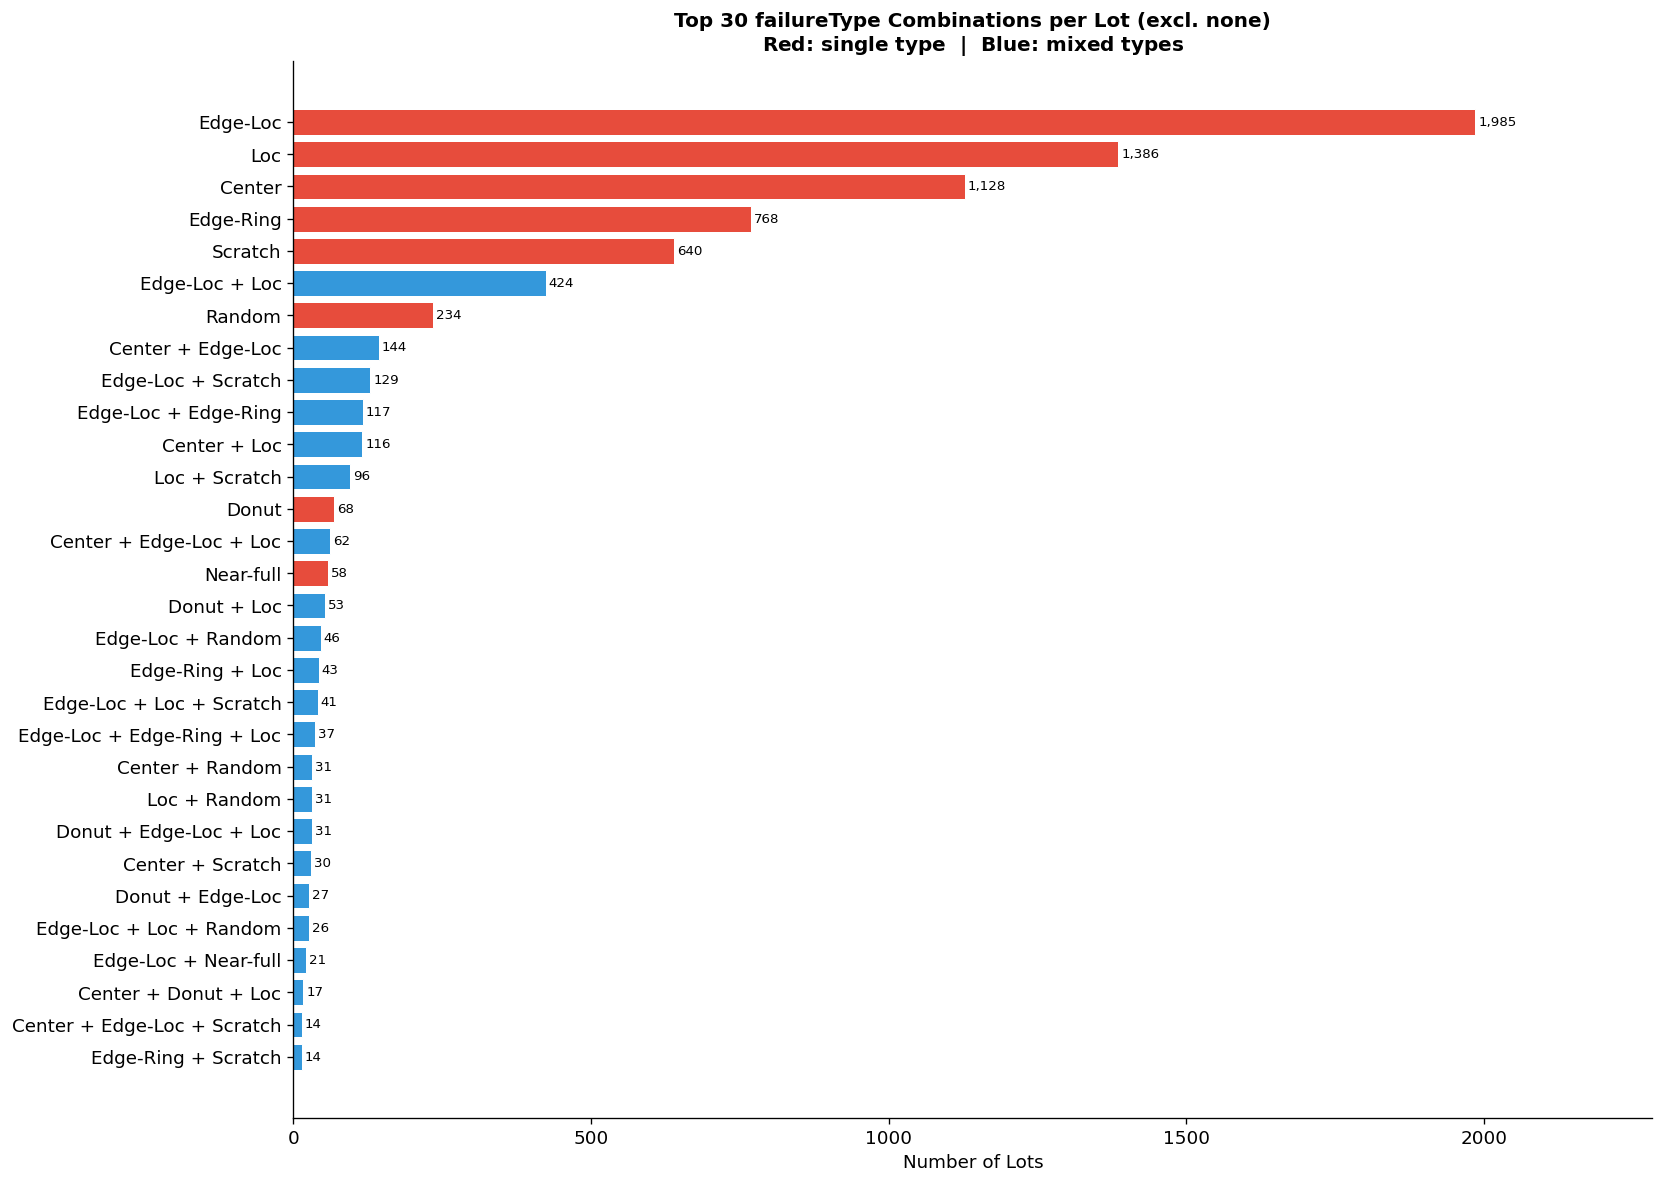

In [22]:
# --- Plot 1: Top 30 combinations bar chart (excl. none) ---
top_n = 30
top_combos = combo_counts.head(top_n)
labels = [' + '.join(c) for c in top_combos.index]

# color: single type vs mixed
bar_colors = ['#e74c3c' if len(c) == 1 else '#3498db' for c in top_combos.index]

fig, ax = plt.subplots(figsize=(14, 10))

bars = ax.barh(labels[::-1], top_combos.values[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, top_combos.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)

ax.set_xlabel('Number of Lots')
ax.set_title(f'Top {top_n} failureType Combinations per Lot (excl. none)\n'
             r'$\bf{Red}$: single type  |  $\bf{Blue}$: mixed types',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, top_combos.max() * 1.15)

plt.tight_layout()
plt.show()

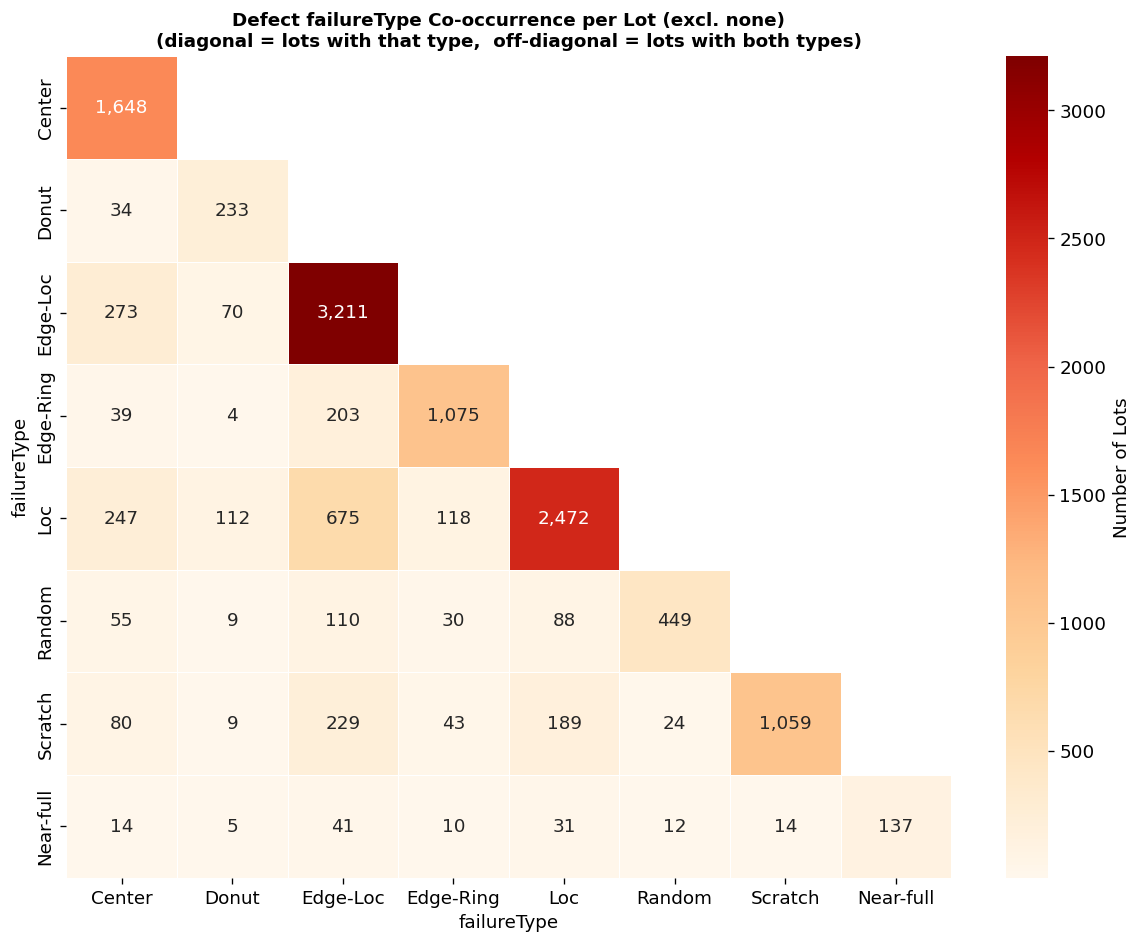

In [23]:
# --- Plot 2: Co-occurrence heatmap (excl. none) ---
# How often do two defect types appear in the same lot?

defect_order = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']
present_types = [f for f in defect_order if f in df_defect['failure_label'].unique()]

cooccurrence = pd.DataFrame(0, index=present_types, columns=present_types)

for combo, cnt in combo_counts.items():
    combo_list = list(combo)
    for i in range(len(combo_list)):
        for j in range(len(combo_list)):
            if combo_list[i] in cooccurrence.index and combo_list[j] in cooccurrence.columns:
                cooccurrence.loc[combo_list[i], combo_list[j]] += cnt

# mask upper triangle for cleaner look
import numpy as np
mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cooccurrence,
    annot=True,
    fmt=',d',
    cmap='OrRd',
    linewidths=0.5,
    mask=mask,
    ax=ax,
    cbar_kws={'label': 'Number of Lots'}
)
ax.set_title('Defect failureType Co-occurrence per Lot (excl. none)\n'
             '(diagonal = lots with that type,  off-diagonal = lots with both types)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('failureType')
ax.set_ylabel('failureType')
plt.tight_layout()
plt.show()

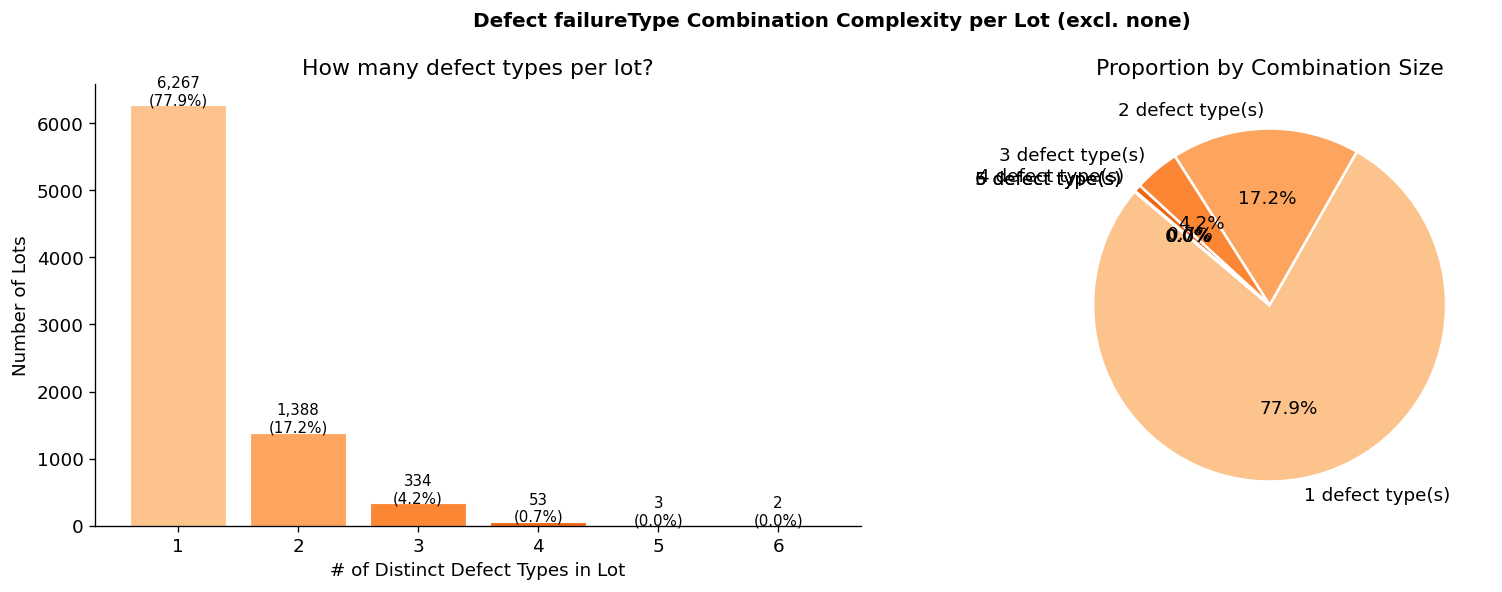


=== Combination Complexity Summary (excl. none) ===


,# Lots,Ratio (%)
# Defect Types,,
1,6267,77.88
2,1388,17.25
3,334,4.15
4,53,0.66
5,3,0.04
6,2,0.02


In [24]:
# --- Plot 3: Combination complexity distribution (excl. none) ---
# How many distinct defect failureTypes does each lot contain?

combo_size = lot_failure_sets.apply(len)
size_counts = combo_size.value_counts().sort_index()

palette = plt.cm.Oranges(np.linspace(0.3, 0.85, len(size_counts)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Defect failureType Combination Complexity per Lot (excl. none)',
             fontsize=12, fontweight='bold')

# bar chart
bars = axes[0].bar(size_counts.index, size_counts.values,
                   color=palette, edgecolor='white', linewidth=0.7)
for bar, val in zip(bars, size_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'{val:,}\n({val/len(lot_failure_sets)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[0].set_xlabel('# of Distinct Defect Types in Lot')
axes[0].set_ylabel('Number of Lots')
axes[0].set_title('How many defect types per lot?')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_xticks(size_counts.index)

# pie chart
axes[1].pie(
    size_counts.values,
    labels=[f'{n} defect type(s)' for n in size_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=palette,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Proportion by Combination Size')

plt.tight_layout()
plt.show()

print("\n=== Combination Complexity Summary (excl. none) ===")
summary_df = pd.DataFrame({
    '# Defect Types': size_counts.index,
    '# Lots': size_counts.values,
    'Ratio (%)': (size_counts.values / len(lot_failure_sets) * 100).round(2)
}).set_index('# Defect Types')
display(summary_df)